In [1]:
import pandas as pd

df = pd.read_csv('../data/raw_analyst_ratings.csv')  
df.head(10)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 09:07:04-04:00,A
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 08:37:59-04:00,A
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-05-22 08:06:17-04:00,A


Descriptive statistics


In [2]:
df['headline_length'] = df['headline'].apply(len)
df['headline_length'].describe()


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

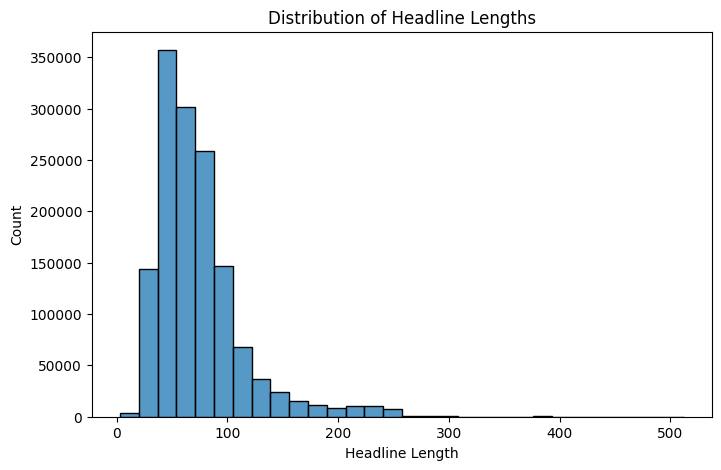

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['headline_length'], bins=30)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Count")
plt.show()


Article per publisher

In [4]:
df['publisher'].value_counts().head(10)


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Bar chart

<Axes: title={'center': 'Top 10 Publishers'}, xlabel='publisher'>

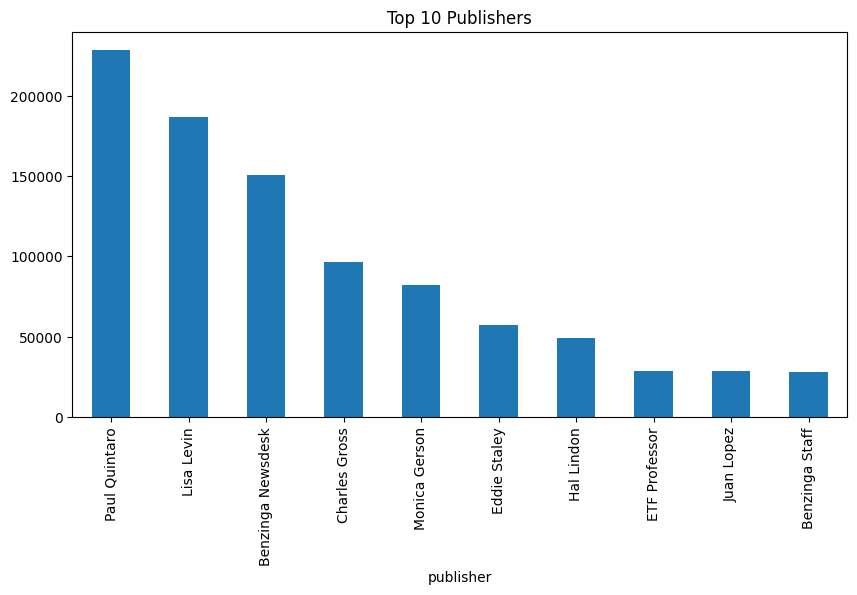

In [5]:
df['publisher'].value_counts().head(10).plot(kind='bar', figsize=(10,5), title="Top 10 Publishers")


Publication trends over time

In [10]:
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')


<Axes: title={'center': 'Articles Published Over Time'}, xlabel='date_only'>

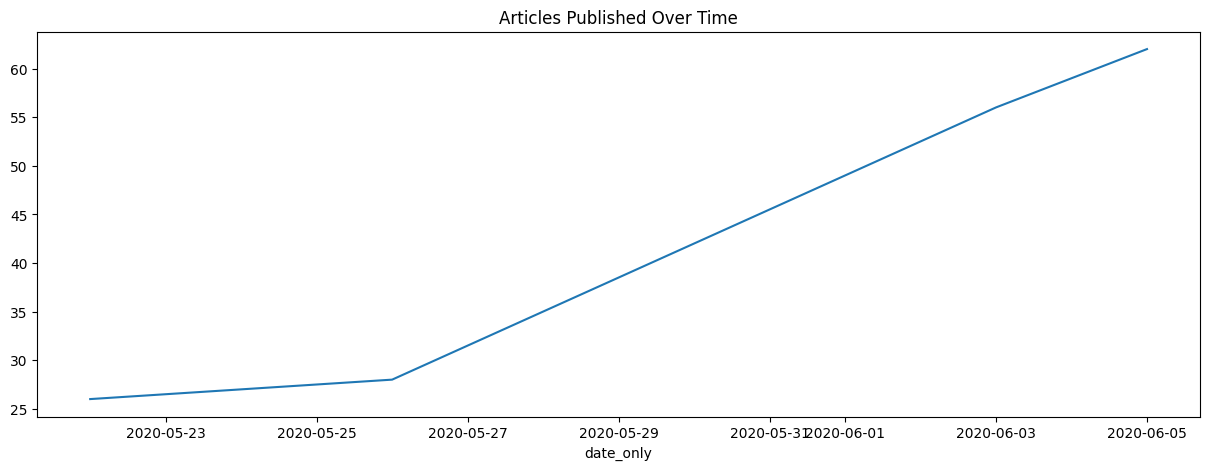

In [11]:
df['date_only'] = df['date'].dt.date
articles_per_day = df.groupby('date_only').size()

articles_per_day.plot(figsize=(15, 5), title="Articles Published Over Time")


Text Analysis (Topic Modeling)

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['headline'])

keywords = vectorizer.get_feature_names_out()
print("Top Keywords:", keywords)


Top Keywords: ['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


Time Series Analysis (by hour of day)

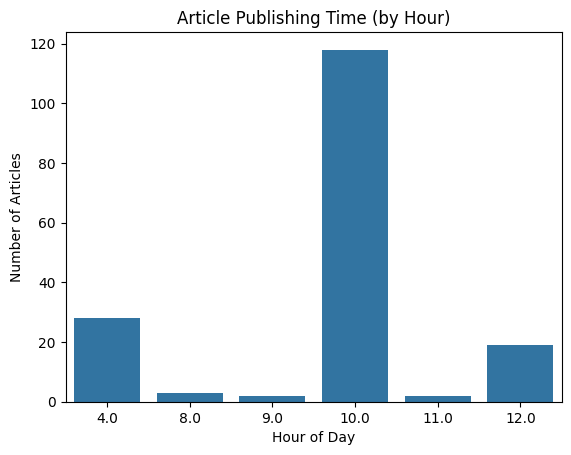

In [13]:
df['hour'] = df['date'].dt.hour

sns.countplot(data=df, x='hour')
plt.title("Article Publishing Time (by Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.show()


 Publisher Analysis (email domain grouping)

In [14]:
df['publisher_domain'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in x else x)
df['publisher_domain'].value_counts().head(10)


publisher_domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Extract domain from emails

email_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


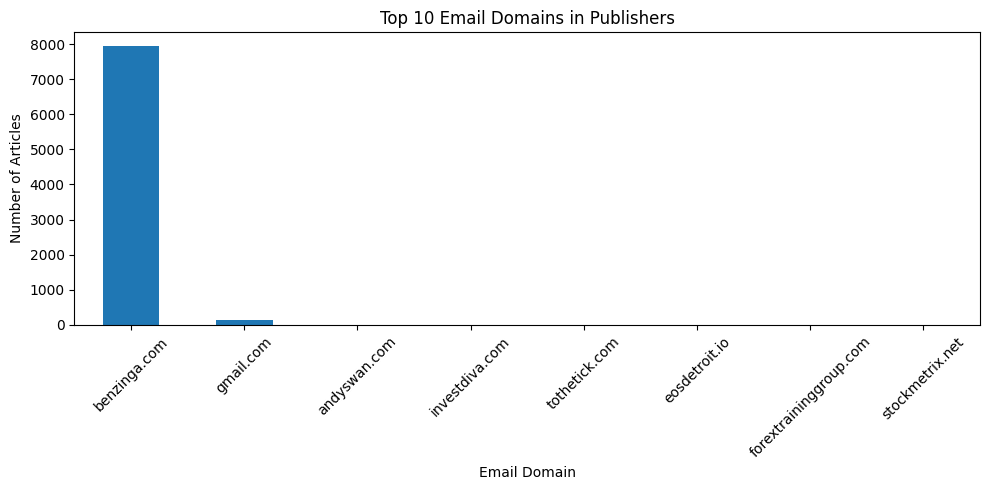

In [16]:
df['email_domain'] = df['publisher'].str.extract(r'@(\w+\.\w+)')

# Top domains (excluding NaN)
top_domains = df['email_domain'].value_counts().head(10)
print(top_domains)

# Plot
top_domains.plot(kind='bar', figsize=(10,5), title='Top 10 Email Domains in Publishers')
plt.xlabel('Email Domain')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
